In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
USING_KAGGLE = True
import os
import math
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
#%pip install uv -q
!mkdir best_run_plots tuned_run_plots default_run_plots varying_rs_run_plots
%pip install pyngrok mlflow lion_pytorch adabound torch-optimizer optax ray[tune] adabelief-pytorch==0.2.0 -q
%pip install --upgrade seaborn -q
%pip install protobuf==3.20.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 63.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━

In [3]:
import time
import inspect

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchmetrics import MetricCollection
from torchmetrics.classification import MulticlassROC
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score, MulticlassPrecision, MulticlassRecall
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torchvision.transforms import v2, ToTensor
from torchvision.models import resnet18
from torchinfo import summary

import pytorch_lightning as pl
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning import seed_everything

import numpy as np

import pandas as pd

import mlflow
import mlflow.pytorch
from mlflow.tracking import MlflowClient

import random

import seaborn as sns

import ray
from ray.train.torch import enable_reproducibility
from ray import tune
from ray.tune.integration.pytorch_lightning import TuneReportCallback
from ray.air.integrations.mlflow import MLflowLoggerCallback, setup_mlflow
from ray.tune import JupyterNotebookReporter
from ray.tune.schedulers import ASHAScheduler

from pprint import pprint

from torch.optim import AdamW
from torch_optimizer import Adahessian as AdaHessian
from adabelief_pytorch import AdaBelief
from lion_pytorch import Lion

import matplotlib.pyplot as plt


In [4]:
from torch.optim import Optimizer


class AdaBound(Optimizer):
    """Implements AdaBound algorithm.
    It has been proposed in `Adaptive Gradient Methods with Dynamic Bound of Learning Rate`_.
    Arguments:
        params (iterable): iterable of parameters to optimize or dicts defining
            parameter groups
        lr (float, optional): Adam learning rate (default: 1e-3)
        betas (Tuple[float, float], optional): coefficients used for computing
            running averages of gradient and its square (default: (0.9, 0.999))
        final_lr (float, optional): final (SGD) learning rate (default: 0.1)
        gamma (float, optional): convergence speed of the bound functions (default: 1e-3)
        eps (float, optional): term added to the denominator to improve
            numerical stability (default: 1e-8)
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
        amsbound (boolean, optional): whether to use the AMSBound variant of this algorithm
    .. Adaptive Gradient Methods with Dynamic Bound of Learning Rate:
        https://openreview.net/forum?id=Bkg3g2R9FX
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        betas=(0.9, 0.999),
        final_lr=0.1,
        gamma=1e-3,
        eps=1e-8,
        weight_decay=0,
        amsbound=False,
    ):
        if not 0.0 <= lr:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if not 0.0 <= eps:
            raise ValueError("Invalid epsilon value: {}".format(eps))
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError("Invalid beta parameter at index 0: {}".format(betas[0]))
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError("Invalid beta parameter at index 1: {}".format(betas[1]))
        if not 0.0 <= final_lr:
            raise ValueError("Invalid final learning rate: {}".format(final_lr))
        if not 0.0 <= gamma < 1.0:
            raise ValueError("Invalid gamma parameter: {}".format(gamma))
        defaults = dict(
            lr=lr,
            betas=betas,
            final_lr=final_lr,
            gamma=gamma,
            eps=eps,
            weight_decay=weight_decay,
            amsbound=amsbound,
        )
        super(AdaBound, self).__init__(params, defaults)

        self.base_lrs = list(map(lambda group: group["lr"], self.param_groups))

    def __setstate__(self, state):
        super(AdaBound, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault("amsbound", False)

    def step(self, closure=None):
        """Performs a single optimization step.
        Arguments:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = 0
        if closure is not None:
            loss = closure()

        for group, base_lr in zip(self.param_groups, self.base_lrs):
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError(
                        "Adam does not support sparse gradients, please consider SparseAdam instead"
                    )
                amsbound = group["amsbound"]

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state["step"] = 0
                    # Exponential moving average of gradient values
                    state["exp_avg"] = torch.zeros_like(p.data)
                    # Exponential moving average of squared gradient values
                    state["exp_avg_sq"] = torch.zeros_like(p.data)
                    if amsbound:
                        # Maintains max of all exp. moving avg. of sq. grad. values
                        state["max_exp_avg_sq"] = torch.zeros_like(p.data)

                exp_avg, exp_avg_sq = state["exp_avg"], state["exp_avg_sq"]
                if amsbound:
                    max_exp_avg_sq = state["max_exp_avg_sq"]
                beta1, beta2 = group["betas"]

                state["step"] += 1

                if group["weight_decay"] != 0:
                    # grad = grad.add(group['weight_decay'], p.data)
                    grad = grad.add(p.data, alpha=group["weight_decay"])

                # Decay the first and second moment running average coefficient
                # exp_avg.mul_(beta1).add_(1 - beta1, grad)
                # exp_avg_sq.mul_(beta2).addcmul_(1 - beta2, grad, grad)
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                if amsbound:
                    # Maintains the maximum of all 2nd moment running avg. till now
                    torch.max(max_exp_avg_sq, exp_avg_sq, out=max_exp_avg_sq)
                    # Use the max. for normalizing running avg. of gradient
                    denom = max_exp_avg_sq.sqrt().add_(group["eps"])
                else:
                    denom = exp_avg_sq.sqrt().add_(group["eps"])

                bias_correction1 = 1 - beta1 ** state["step"]
                bias_correction2 = 1 - beta2 ** state["step"]
                step_size = group["lr"] * math.sqrt(bias_correction2) / bias_correction1

                # Applies bounds on actual learning rate
                # lr_scheduler cannot affect final_lr, this is a workaround to apply lr decay
                final_lr = group["final_lr"] * group["lr"] / base_lr
                lower_bound = final_lr * (1 - 1 / (group["gamma"] * state["step"] + 1))
                upper_bound = final_lr * (1 + 1 / (group["gamma"] * state["step"]))
                step_size = torch.full_like(denom, step_size)
                step_size.div_(denom).clamp_(lower_bound, upper_bound).mul_(exp_avg)

                p.data.add_(-step_size)

        return loss


In [5]:
SEED = 0
NUM_THREADS = 4
def setup(working_dir: str = ".") -> None:
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    pd.set_option("display.max_colwidth", None)
    ray.shutdown()
    ray.init(
       runtime_env={
           "env_vars": {"RAY_AIR_RICH_LAYOUT": "1"},
           "working_dir": working_dir,
       },
    )
    resources = ray.cluster_resources()
    pprint(resources)
    torch.set_num_threads(NUM_THREADS)

def seed_worker(worker_id: int):
    np.random.seed(SEED)
    random.seed(SEED)


def get_or_create_experiment(experiment_name):
    """
    Retrieve the ID of an existing MLflow experiment or create a new one if it doesn't exist.
    
    This function checks if an experiment with the given name exists within MLflow.
    If it does, the function returns its ID. If not, it creates a new experiment
    with the provided name and returns its ID.
    
    Parameters:
    - experiment_name (str): Name of the MLflow experiment.
    
    Returns:
    - str: ID of the existing or newly created MLflow experiment.
    """
    
    if experiment := mlflow.get_experiment_by_name(experiment_name):
        return experiment.experiment_id
    return mlflow.create_experiment(experiment_name)

from pyngrok import ngrok
from getpass import getpass

ngrok.kill()
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
NGROK_AUTH_TOKEN = user_secrets.get_secret("NGROK_AUTH_TOKEN")

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

setup(".")
experiment_name = "image_classification"
#mlflow.set_tracking_uri(tracking_uri)
experiment_id = get_or_create_experiment("image_classification")

mlflow.set_tracking_uri("./mlruns") 
mlflow.set_experiment(experiment_name)

get_ipython().system_raw("mlflow ui --backend-store-uri ./mlruns --host 0.0.0.0 &")
public_url = ngrok.connect(5000, "http", host_header="localhost:5000")
tracking_uri = "./mlruns"
client = MlflowClient()
print(f"✅ MLflow UI is live at: {public_url}")

2025-10-27 18:51:35,524	INFO worker.py:1951 -- Started a local Ray instance.
2025-10-27 18:51:35,536	INFO packaging.py:588 -- Creating a file package for local module '.'.
2025-10-27 18:51:35,539	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_f1c09c68cbf64041.zip' (0.00MiB) to Ray cluster...
2025-10-27 18:51:35,542	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_f1c09c68cbf64041.zip'.


{'CPU': 4.0,
 'GPU': 2.0,
 'accelerator_type:T4': 1.0,
 'memory': 21591730586.0,
 'node:172.19.2.2': 1.0,
 'node:__internal_head__': 1.0,
 'object_store_memory': 9253598822.0}
✅ MLflow UI is live at: NgrokTunnel: "https://6aa01f450489.ngrok-free.app" -> "http://localhost:5000"


In [6]:

classes = ['plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torchmetrics import MetricCollection
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score, MulticlassPrecision, MulticlassRecall


class LightningWrapper(pl.LightningModule):
    def __init__(self, model: nn.Module, optimizer_class, optimizer_hparams: dict, loss_fn: nn.Module, num_classes: int=num_classes):
        super().__init__()
        self.model = model
        # We don't need to store optimizer_class anymore, but it's harmless
        self.optimizer_class = optimizer_class
        self.loss_fn = loss_fn
        # Use a specific num_classes argument for clarity
        self.num_classes = num_classes 
        
        self.save_hyperparameters(ignore=['model', 'loss_fn', 'optimizer_class'])
        
        # This is correct, you must disable automatic optimization for this to work.
        self.automatic_optimization = False
        
        metrics = MetricCollection({
            "accuracy": MulticlassAccuracy(num_classes=self.num_classes),
            "f1score": MulticlassF1Score(num_classes=self.num_classes),
            "precision": MulticlassPrecision(num_classes=self.num_classes),
            "recall": MulticlassRecall(num_classes=self.num_classes),
        })
        self.train_metrics = metrics.clone(prefix='train_')
        self.val_metrics = metrics.clone(prefix='val_')
        self.test_metrics = metrics.clone(prefix='test_')

    def forward(self, x):
        return self.model(x)

    # --- THIS IS THE CORRECTED FUNCTION ---
    def training_step(self, batch, batch_idx):
        # 1. Get the optimizer(s) from the trainer
        opt = self.optimizers()
        
        # 2. Forward pass and loss calculation
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)

        # 3. Clear gradients from the previous step
        opt.zero_grad()

        # 4. Backward pass.
        # Check if the INSTANCE of the optimizer is AdaHessian.
        # This is more robust than checking the class type stored at init.
        create_graph_needed = isinstance(opt, AdaHessian)
        self.manual_backward(loss, create_graph=create_graph_needed)

        # 5. Optimizer step
        opt.step()
        
        # NOTE: If you were using a learning rate scheduler, you would also
        # need to step it manually here, e.g., sch.step()
        
        # 6. Logging and metrics
        self.log('train_loss_step', loss, on_step=True, on_epoch=False, prog_bar=True)
        self.log('train_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        self.train_metrics.update(logits, y)
        
        return loss

    def on_train_epoch_end(self):
        self.log_dict(self.train_metrics.compute(), sync_dist=True)
        self.train_metrics.reset()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log('val_loss_step', loss, on_step=True, on_epoch=False, sync_dist=True)
        self.log('val_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        self.val_metrics.update(logits, y)
        return loss

    def on_validation_epoch_end(self):
        self.log_dict(self.val_metrics.compute(), sync_dist=True)
        self.val_metrics.reset()

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log('test_loss', loss, on_step=False, on_epoch=True, sync_dist=True)
        self.test_metrics.update(logits, y)
        return loss

    def on_test_epoch_end(self):
        self.log_dict(self.test_metrics.compute(), sync_dist=True)
        self.test_metrics.reset()
    
    def configure_optimizers(self):
        # Note: self.hparams.optimizer_hparams will be populated by save_hyperparameters()
        optimizer = self.optimizer_class(self.model.parameters(), **self.hparams.optimizer_hparams)
        return optimizer
    # NOTE: The optimizer_step hook has been completely removed as it is not used
    # in manual optimization mode.

In [7]:
transforms = v2.Compose([ToTensor(),
                         v2.ToDtype(torch.float32, scale=True),
                         v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
cifar_trainset = CIFAR10(root='data',
                         train=True,
                         transform=transforms,
                         download=True)
cifar_testset = CIFAR10(root='data',
                        train=False,
                        transform=transforms,
                        download=True)
cifar_train_subset, cifar_valid_subset = random_split(
    cifar_trainset,
    [int(0.8*len(cifar_trainset)), len(cifar_trainset)-int(0.8*len(cifar_trainset))],
)
TORCH_GENERATOR: torch.Generator = torch.Generator()
TORCH_GENERATOR.manual_seed(SEED)
BATCH_SIZE = 128
NUM_EPOCHS = 3


classes = ['plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)

100%|██████████| 170M/170M [00:02<00:00, 81.8MB/s] 
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
INFO:     Uvicorn running on http://0.0.0.0:5000 (Press CTRL+C to quit)
INFO:     Started parent process [466]


In [8]:
INPUT_SHAPE = 32
HIDDEN_UNITS = 64
OUTPUT_SHAPE = num_classes
NUM_EPOCHS = 5
EPOCH_STEP = 1
BATCH_SIZE = 256
SEED = 0

OPTIMIZERS_PARAMS: dict = {
    AdaBelief: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "amsgrad": tune.grid_search([False, True]),
        "weight_decouple": tune.grid_search([False, True]),
        "rectify": tune.grid_search([False, True]),
        "print_change_log": tune.grid_search([False]),
    },
    AdaHessian: {
        "lr": tune.grid_search([1e-2, 1e-1, 0.15, 1.0]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "hessian_power": tune.grid_search([0.5, 0.75, 1.0]),
        "seed": tune.grid_search([SEED]),
    },
    Lion: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([1e-4, 1e-3, 1e-2]),
        "decoupled_weight_decay": tune.grid_search([False, True]),
        "use_triton": tune.grid_search([False]),
    },
    AdamW: {
        "lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3, 1e-2]),
        "amsgrad": tune.grid_search([False, True]),
    },
    AdaBound: {
        "lr": tune.grid_search([1e-5, 1e-4, 1e-3, 1e-2]),
        "final_lr": tune.grid_search([1e-4, 1e-3, 1e-2, 1e-1]),
        "gamma": tune.grid_search([1e-4, 1e-3, 1e-2]),
        "weight_decay": tune.grid_search([0, 1e-4, 1e-3]),
        "amsbound": tune.grid_search([False, True]),
    },
}

cls_analysis_optimizer = {}
classification_metrics = {
            "accuracy": MulticlassAccuracy(num_classes=num_classes),
            "f1score": MulticlassF1Score(num_classes=num_classes),
            "precision": MulticlassPrecision(num_classes=num_classes),
            "recall": MulticlassRecall(num_classes=num_classes),
        }
reporter = JupyterNotebookReporter(metric_columns=["val_loss"], 
                                   mode="min", 
                                   print_intermediate_tables=False)

cifar_train_subset_ref = ray.put(cifar_train_subset)
cifar_valid_subset_ref = ray.put(cifar_valid_subset)
cifar_testset_ref = ray.put(cifar_testset)

mlflow_callback = MLflowLoggerCallback(
    tracking_uri="./mlruns", # Log to a local directory
    experiment_name="mnist_ray_tune_experiment",
    save_artifact=True # Saves checkpoints as MLflow artifacts
)

for metric in classification_metrics:
    reporter.add_metric_column(f"val_{metric}")

for optimizer_type in OPTIMIZERS_PARAMS.keys():
    def wrap(config: dict) -> None:
        """Wrapper function for tuning hyperparameters.
    
        Args:
            config: A dict whose keys are parameters to be tuned and values that the parameter can take.

        """
        cifar_train_dataloader = DataLoader(dataset=ray.get(cifar_train_subset_ref),
                                           batch_size=BATCH_SIZE,
                                           shuffle=True,
                                           num_workers=2,
                                           worker_init_fn=seed_worker,
                                           generator=TORCH_GENERATOR,)
        cifar_valid_dataloader = DataLoader(dataset=ray.get(cifar_valid_subset_ref),
                                           batch_size=BATCH_SIZE,
                                           num_workers=2,
                                           worker_init_fn=seed_worker,
                                           generator=TORCH_GENERATOR,)
        cifar_test_dataloader = DataLoader(dataset=ray.get(cifar_testset_ref),
                                           batch_size=BATCH_SIZE,
                                           num_workers=2,
                                           worker_init_fn=seed_worker,
                                           generator=TORCH_GENERATOR,)
        setup_mlflow(
            config,
            experiment_name=config.get("experiment_name", None),
            tracking_uri=config.get("tracking_uri", None),
        )
        model = resnet18(num_classes=num_classes)
        loss_fn = nn.CrossEntropyLoss()
        wrapper = LightningWrapper(model=model, 
                                   optimizer_class=optimizer_type, 
                                   optimizer_hparams={i: j for i, j in config.items() if i not in ["experiment_name", "tracking_uri"]}, 
                                   loss_fn=loss_fn, )
        tune_callback = TuneReportCallback(
            {
                "val_loss": "val_loss",
                "val_accuracy": "val_accuracy",
                "val_f1score": "val_f1score",
                "val_precision": "val_precision",
                "val_recall": "val_recall",
            },
            on="validation_end"
        )
        # mlflow.pytorch.autolog()
        trainer = pl.Trainer(callbacks=[tune_callback, ],
                            limit_train_batches=BATCH_SIZE, 
                            max_epochs=NUM_EPOCHS,
                            accelerator="auto",
                            devices="auto",
                            enable_progress_bar=False,
                            enable_checkpointing=False,
        )
        
        trainer.fit(model=wrapper, 
                    train_dataloaders=cifar_train_dataloader,
                    val_dataloaders=cifar_valid_dataloader,)
        
    analysis = tune.run(
        wrap,
        config={str(key): value for key, value in OPTIMIZERS_PARAMS[optimizer_type].items()} | 
        {"experiment_name": experiment_name, "tracking_uri": tracking_uri, },
        scheduler=ASHAScheduler(metric='val_accuracy', mode='max'),
        progress_reporter=reporter,
        resources_per_trial={"cpu": 2, 
                             "gpu": 1,
                             },
        log_to_file=True,
        callbacks=[mlflow_callback],
    )
    cls_analysis_optimizer[optimizer_type] = analysis


INFO:     Started server process [469]
INFO:     Waiting for application startup.
INFO:     Started server process [468]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Application startup complete.
INFO:     Started server process [470]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Started server process [471]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
2025-10-27 18:51:52,533	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-spe

(wrap pid=616) AMSGrad enabled in AdaBelief


Trial name,val_accuracy,val_f1score,val_loss,val_precision,val_recall
wrap_00898_00000,0.532562,0.533834,1.59204,0.538583,0.532562
wrap_00898_00001,0.480958,0.474546,1.45539,0.47681,0.480958
wrap_00898_00002,0.675292,0.671551,0.996618,0.695053,0.675292
wrap_00898_00003,0.684297,0.683451,0.974127,0.696896,0.684297
wrap_00898_00004,0.406814,0.388362,1.63946,0.423354,0.406814
wrap_00898_00005,0.399864,0.373607,1.67798,0.422264,0.399864
wrap_00898_00006,0.237557,0.200399,2.17187,0.241971,0.237557
wrap_00898_00007,0.197947,0.122068,2.09553,0.0946633,0.197947
wrap_00898_00008,0.36086,0.356343,1.77809,0.355565,0.36086
wrap_00898_00009,0.357232,0.350584,1.78359,0.34962,0.357232


(wrap pid=816) /usr/local/lib/python3.11/dist-packages/ray/train/context.py:131: RayDeprecationWarning: `ray.train.get_context()` should be switched to `ray.tune.get_context()` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context and migration options: https://github.com/ray-project/ray/issues/49454. Disable these warnings by setting the environment variable: RAY_TRAIN_ENABLE_V2_MIGRATION_WARNINGS=0 [repeated 2x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(wrap pid=816)   _log_deprecation_warning( [repeated 2x across cluster]
(wrap pid=816) /usr/local/lib/python3.11/dist-packages/ray/air/integrations/mlflow.py:153: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setti

(wrap pid=1005) AMSGrad enabled in AdaBelief


...

(wrap pid=23698) /usr/local/lib/python3.11/dist-packages/ray/train/context.py:131: RayDeprecationWarning: `ray.train.get_context()` should be switched to `ray.tune.get_context()` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context and migration options: https://github.com/ray-project/ray/issues/49454. Disable these warnings by setting the environment variable: RAY_TRAIN_ENABLE_V2_MIGRATION_WARNINGS=0 [repeated 2x across cluster]
(wrap pid=23698)   _log_deprecation_warning( [repeated 2x across cluster]
(wrap pid=23698) /usr/local/lib/python3.11/dist-packages/ray/air/integrations/mlflow.py:153: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning" [repeated 2x across cluster]
(wrap pid=23698) `get_world_rank` is deprecated for Ray Tune because there is no concept of worker ranks for Ray Tune,

Trial name,val_accuracy,val_f1score,val_loss,val_precision,val_recall
wrap_e478c_00000,0.532199,0.531234,1.57843,0.534582,0.532199
wrap_e478c_00001,0.475871,0.469512,1.44625,0.471917,0.475871
wrap_e478c_00002,0.69321,0.691563,0.91627,0.701791,0.69321
wrap_e478c_00003,0.681653,0.677161,0.995848,0.693885,0.681653
wrap_e478c_00004,0.42249,0.401178,1.60765,0.448635,0.42249
wrap_e478c_00005,0.385858,0.360391,1.7304,0.395971,0.385858
wrap_e478c_00006,0.100296,0.018952,2.30775,0.0600629,0.100296
wrap_e478c_00007,0.0996957,0.0179151,2.31077,0.00984181,0.0996957
wrap_e478c_00008,0.469635,0.463505,1.46085,0.464636,0.469635
wrap_e478c_00009,0.469791,0.463872,1.44919,0.464703,0.469791


(wrap pid=26617) Exception ignored in atexit callback: <function shutdown at 0x79ba485a2020>
(wrap pid=26617) Traceback (most recent call last):
(wrap pid=26617)   File "/usr/lib/python3.11/logging/__init__.py", line 2186, in shutdown
(wrap pid=26617)     h.close()
(wrap pid=26617)   File "/usr/local/lib/python3.11/dist-packages/absl/logging/__init__.py", line 944, in close
(wrap pid=26617)     self.stream.close()
(wrap pid=26617)     ^^^^^^^^^^^^^^^^^
(wrap pid=26617) AttributeError: 'Tee' object has no attribute 'close'
(wrap pid=26617) /usr/local/lib/python3.11/dist-packages/ray/train/context.py:131: RayDeprecationWarning: `ray.train.get_context()` should be switched to `ray.tune.get_context()` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context and migration options: https://github.com/ray-project/ray/issues/49454. Disable these warnings by setting the environment variable: RAY_TRAIN_ENABLE_V2_MIGRATION_WARNINGS=0
(wra

Trial name,val_accuracy,val_f1score,val_loss,val_precision,val_recall
wrap_ee03d_00000,0.412241,0.408538,1.62744,0.407267,0.412241
wrap_ee03d_00001,0.297481,0.292223,1.94499,0.296236,0.297481
wrap_ee03d_00002,0.427942,0.423665,1.58815,0.423504,0.427942
wrap_ee03d_00003,0.299394,0.291757,1.96018,0.290992,0.299394
wrap_ee03d_00004,0.434219,0.431429,1.5808,0.431134,0.434219
wrap_ee03d_00005,0.432508,0.429006,1.59368,0.428146,0.432508
wrap_ee03d_00006,0.303132,0.296941,1.93469,0.296328,0.303132
wrap_ee03d_00007,0.496238,0.491891,1.4082,0.494999,0.496238
wrap_ee03d_00008,0.238639,0.225911,2.08893,0.245838,0.238639
wrap_ee03d_00009,0.2676,0.260177,2.04109,0.266501,0.2676


(wrap pid=31090) /usr/local/lib/python3.11/dist-packages/ray/train/context.py:131: RayDeprecationWarning: `ray.train.get_context()` should be switched to `ray.tune.get_context()` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context and migration options: https://github.com/ray-project/ray/issues/49454. Disable these warnings by setting the environment variable: RAY_TRAIN_ENABLE_V2_MIGRATION_WARNINGS=0 [repeated 2x across cluster]
(wrap pid=31090)   _log_deprecation_warning( [repeated 2x across cluster]
(wrap pid=31090) /usr/local/lib/python3.11/dist-packages/ray/air/integrations/mlflow.py:153: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning" [repeated 2x across cluster]
(wrap pid=31090) `get_world_rank` is deprecated for Ray Tune because there is no concept of worker ranks for Ray Tune,

In [9]:
def get_mlflow_run_id_from_trial(experiment_name: str, trial) -> str | None:
    """
    Finds the MLflow run ID by searching for a run with a 'trial_name' tag
    that matches the string representation of the Ray Tune Trial.

    Args:
        experiment_name: The name of the MLflow experiment.
        trial: The Ray Tune Trial object.

    Returns:
        The MLflow run ID as a string, or None if not found.
    """
    try:
        experiment = client.get_experiment_by_name(experiment_name)
        if not experiment:
            print(f"Error: Experiment '{experiment_name}' not found.")
            return None
        experiment_id = experiment.experiment_id

        # THIS IS THE CORRECTED FILTER
        # Search for a run where the tag 'trial_name' matches the trial's string name.
        filter_string = f"tags.`trial_name` = '{str(trial)}'"
        runs = client.search_runs(experiment_ids=[experiment_id], filter_string=filter_string)

        if not runs:
            print(f"Warning: No MLflow run found for trial '{trial_name_str}'")
            return None
        
        # In case of duplicates, which shouldn't happen, use the first one.
        return runs[0].info.run_id

    except Exception as e:
        print(f"An error occurred while searching for MLflow run for trial {trial_name_str}: {e}")
        return None

def get_metric_history_df(run_id: str, metric_name: str) -> pd.DataFrame:
    """Fetches the full history of a metric for a given run and returns it as a DataFrame."""
    history = client.get_metric_history(run_id, metric_name)
    
    # Convert the list of Metric objects to a DataFrame
    df = pd.DataFrame(
        [{'step': m.step, 'value': m.value, 'timestamp': m.timestamp} for m in history]
    )
    # Convert timestamp to a readable format (optional)`
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    return df

val_metric_dfs = {}
for opt_cls in OPTIMIZERS_PARAMS:
    analysis = cls_analysis_optimizer[opt_cls]
    best_trial = analysis.get_best_trial(metric=f"val_accuracy", mode="max")
    mlflow_run_id = get_mlflow_run_id_from_trial(experiment_name, best_trial)
    val_metric_dfs[opt_cls] = {}
    val_metric_dfs[opt_cls]['loss'] = get_metric_history_df(mlflow_run_id, "val_loss")
    val_metric_dfs[opt_cls]['accuracy'] = get_metric_history_df(mlflow_run_id, "val_accuracy")
    val_metric_dfs[opt_cls]['f1score'] = get_metric_history_df(mlflow_run_id, "val_f1score")
    val_metric_dfs[opt_cls]['precision'] = get_metric_history_df(mlflow_run_id, "val_precision")
    val_metric_dfs[opt_cls]['recall'] = get_metric_history_df(mlflow_run_id, "val_recall")
    print(f"Running for {opt_cls=}")
    print("\nValidation Loss History:")
    print(val_metric_dfs[opt_cls]['loss'].head())

(wrap pid=69265) 2025-10-27 23:09:18,153	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-10-27_18-51-29_529244_37/artifacts/2025-10-27_20-53-02/wrap_2025-10-27_20-53-02/working_dirs/wrap_ee03d_00287_287_amsbound=True,final_lr=0.1000,gamma=0.0100,lr=0.0100,weight_decay=0.0010_2025-10-27_21-40-27/stderr' mode='a+' encoding='utf-8'>). args: () kwargs: {}
(wrap pid=69265) 2025-10-27 23:09:18,153	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-10-27_18-51-29_529244_37/artifacts/2025-10-27_20-53-02/wrap_2025-10-27_20-53-02/working_dirs/wrap_ee03d_00287_287_amsbound=True,final_lr=0.1000,gamma=0.0100,lr=0.0100,weight_decay=0.0010_2025-10-27_21-40-27/stderr' mode='a+' encoding='utf-8'>). args: () kwargs: {}
(wrap pid=69265) 2025-10-27 23:09:18,153	WARNING util.py:226 -- ValueError when calling 'flush' on stream (<_io.TextIOWrapper name='/tmp/ray/session_2025-10-27_18

Running for opt_cls=<class 'adabelief_pytorch.AdaBelief.AdaBelief'>

Validation Loss History:
   step     value               timestamp
0     1  1.467111 2025-10-27 19:45:31.666
1     2  1.189776 2025-10-27 19:45:44.914
2     3  1.110240 2025-10-27 19:46:00.552
3     4  0.929868 2025-10-27 19:46:16.227
4     5  0.911471 2025-10-27 19:46:31.802
Running for opt_cls=<class 'torch_optimizer.adahessian.Adahessian'>

Validation Loss History:
   step     value               timestamp
0     1  1.385924 2025-10-27 19:53:53.954
1     2  1.267079 2025-10-27 19:54:28.790
2     3  1.130314 2025-10-27 19:55:03.940
3     4  0.978373 2025-10-27 19:55:38.962
4     5  0.938928 2025-10-27 19:56:14.048
Running for opt_cls=<class 'lion_pytorch.lion_pytorch.Lion'>

Validation Loss History:
   step     value               timestamp
0     1  1.363434 2025-10-27 20:33:10.162
1     2  1.143294 2025-10-27 20:33:22.232
2     3  0.905134 2025-10-27 20:33:34.475
3     4  0.864726 2025-10-27 20:33:48.391
4     5  0.

In [10]:
runs = mlflow.search_runs()
runs.sort_values('start_time', ascending=False)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.pid,metrics.val_loss,metrics.val_precision,metrics.done,...,params.amsgrad,params.decoupled_weight_decay,params.use_triton,params.seed,params.hessian_power,params.weight_decouple,params.rectify,params.print_change_log,tags.trial_name,tags.mlflow.runName
0,660a918e959d4f0e87bc59c3e4cc4498,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/660a918e959d4f0e87bc59c3e4cc4498/artifacts,2025-10-27 23:09:00.257000+00:00,2025-10-27 23:09:17.499000+00:00,69265.0,1.563507,0.414272,1.0,...,None,None,None,None,None,None,None,None,wrap_ee03d_00287,wrap_ee03d_00287
1,fadb2c9184804557aa549cf9eb9739a1,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/fadb2c9184804557aa549cf9eb9739a1/artifacts,2025-10-27 23:08:14.856000+00:00,2025-10-27 23:08:37.780000+00:00,69081.0,1.661598,0.412794,1.0,...,None,None,None,None,None,None,None,None,wrap_ee03d_00286,wrap_ee03d_00286
2,7773b99a12f44baf9bb8b03fd9fe9e73,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/7773b99a12f44baf9bb8b03fd9fe9e73/artifacts,2025-10-27 23:07:55.122000+00:00,2025-10-27 23:08:57.504000+00:00,68964.0,1.332612,0.535409,1.0,...,None,None,None,None,None,None,None,None,wrap_ee03d_00285,wrap_ee03d_00285
3,b8dc5c15a2594defaa8925bbcbba81e1,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/b8dc5c15a2594defaa8925bbcbba81e1/artifacts,2025-10-27 23:07:36.779000+00:00,2025-10-27 23:07:55.329000+00:00,68852.0,1.448446,0.474573,1.0,...,None,None,None,None,None,None,None,None,wrap_ee03d_00284,wrap_ee03d_00284
4,8588d27e592b4135b9080ead472c1185,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/8588d27e592b4135b9080ead472c1185/artifacts,2025-10-27 23:07:17.457000+00:00,2025-10-27 23:07:35.676000+00:00,68735.0,1.838270,0.327012,1.0,...,None,None,None,None,None,None,None,None,wrap_ee03d_00283,wrap_ee03d_00283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,e86d217855d2459aa5187cca70ba0b5f,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/e86d217855d2459aa5187cca70ba0b5f/artifacts,2025-10-27 18:55:06.257000+00:00,2025-10-27 18:55:27.777000+00:00,1179.0,1.639462,0.423354,1.0,...,False,None,None,None,None,False,False,False,wrap_00898_00004,wrap_00898_00004
516,a307da10bdad4cc0a33e934c7bcb161f,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/a307da10bdad4cc0a33e934c7bcb161f/artifacts,2025-10-27 18:54:22.026000+00:00,2025-10-27 18:55:35.400000+00:00,1005.0,0.974127,0.696896,0.0,...,True,None,None,None,None,False,False,False,wrap_00898_00003,wrap_00898_00003
517,d66bf67ac503422aaf3d17bbabc55c04,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/d66bf67ac503422aaf3d17bbabc55c04/artifacts,2025-10-27 18:53:29.718000+00:00,2025-10-27 18:54:42.963000+00:00,816.0,0.996618,0.695053,0.0,...,False,None,None,None,None,False,False,False,wrap_00898_00002,wrap_00898_00002
518,21714abe0fed4221a304118aab525a3c,393002126913728322,FINISHED,file:///kaggle/working/mlruns/393002126913728322/21714abe0fed4221a304118aab525a3c/artifacts,2025-10-27 18:52:31.513000+00:00,2025-10-27 18:53:07.077000+00:00,616.0,1.455389,0.476810,1.0,...,True,None,None,None,None,False,False,False,wrap_00898_00001,wrap_00898_00001



Plot saved to best_run_plots/best_run_loss.png


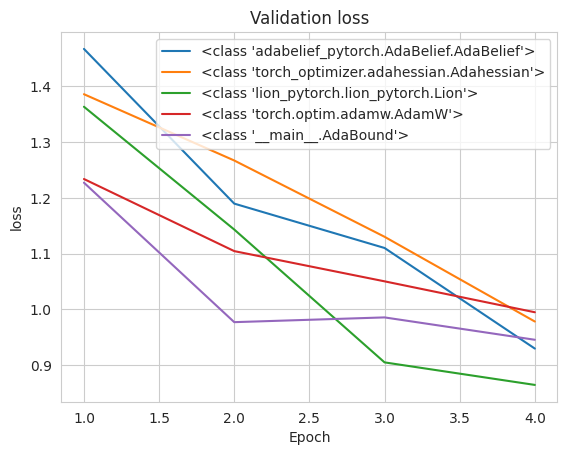


Plot saved to best_run_plots/best_run_accuracy.png


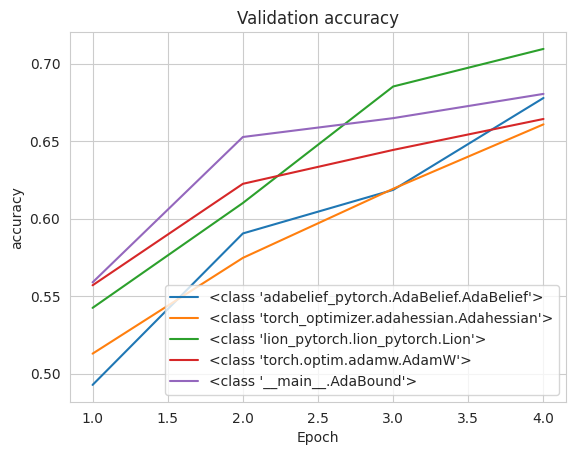


Plot saved to best_run_plots/best_run_f1score.png


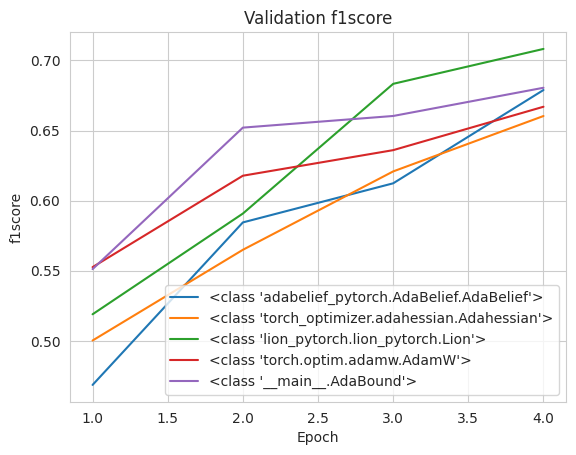


Plot saved to best_run_plots/best_run_precision.png


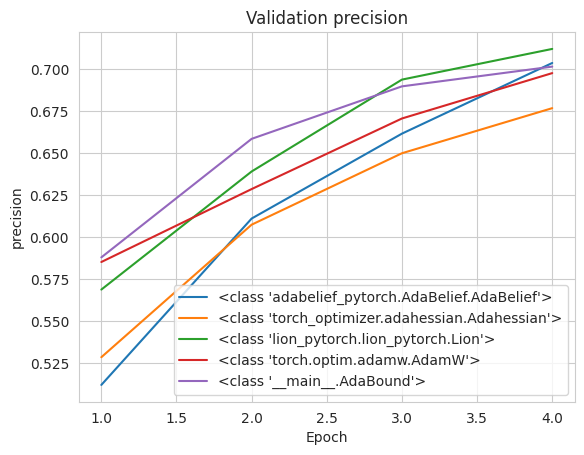


Plot saved to best_run_plots/best_run_recall.png


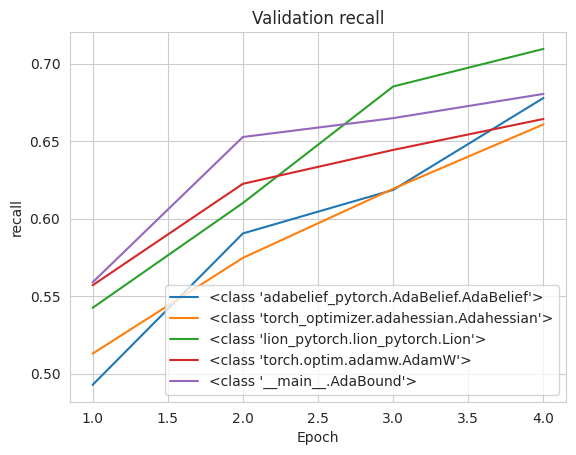

In [11]:
sns.set_style("whitegrid")

for metric in val_metric_dfs[next(iter(val_metric_dfs))]:
    for opt_cls in val_metric_dfs:
        plt.plot(val_metric_dfs[opt_cls][metric]['step'][:-1], val_metric_dfs[opt_cls][metric]['value'][:-1], label=opt_cls)
    plt.title(f'Validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    output_filename = f"best_run_plots/best_run_{metric}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved to {output_filename}")
    plt.show()

In [12]:
optimizer_comparison_acc_df = pd.DataFrame({"Optimizer": [repr(i)[repr(i).rfind('.') + 1: -2] for i in cls_analysis_optimizer], 
                                            "Config": [i.get_best_config(metric=f"val_accuracy", mode="max") for i in cls_analysis_optimizer.values()], 
                                            "Accuracy": [i.get_best_trial(metric=f"val_accuracy", mode="max").last_result[f"val_accuracy"] for i in cls_analysis_optimizer.values() ], 
                                            "F1Score": [i.get_best_trial(metric=f"val_accuracy", mode="max").last_result[f"val_f1score"] for i in cls_analysis_optimizer.values()], 
                                            "Precision": [i.get_best_trial(metric=f"val_accuracy", mode="max").last_result[f"val_precision"] for i in cls_analysis_optimizer.values()], 
                                            "Recall": [i.get_best_trial(metric=f"val_accuracy", mode="max").last_result[f"val_recall"] for i in cls_analysis_optimizer.values()], 
                                            "Time_total_s": [round(i.get_best_trial(metric=f"val_accuracy", mode="max").last_result['time_total_s'], 2) for i in cls_analysis_optimizer.values()],
                                           })

optimizer_comparison_acc_df

,Optimizer,Config,Accuracy,F1Score,Precision,Recall,Time_total_s
0,AdaBelief,"{'lr': 0.01, 'weight_decay': 0.01, 'amsgrad': False, 'weight_decouple': True, 'rectify': True, 'print_change_log': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}",0.691264,0.691346,0.707257,0.691264,78.53
1,Adahessian,"{'lr': 0.1, 'weight_decay': 0, 'hessian_power': 0.75, 'seed': 0, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}",0.686110,0.685916,0.696668,0.686110,181.21
2,Lion,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}",0.717447,0.717769,0.721252,0.717447,72.58
3,AdamW,"{'lr': 0.001, 'weight_decay': 0, 'amsgrad': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}",0.693210,0.691563,0.701791,0.693210,74.56
4,AdaBound,"{'lr': 0.001, 'final_lr': 0.01, 'gamma': 0.0001, 'weight_decay': 0, 'amsbound': True, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}",0.708059,0.709376,0.714465,0.708059,76.02


In [13]:
cifar_train_dataloader = DataLoader(dataset=ray.get(cifar_train_subset_ref),
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)
cifar_valid_dataloader = DataLoader(dataset=ray.get(cifar_valid_subset_ref),
                                   batch_size=BATCH_SIZE,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)
cifar_test_dataloader = DataLoader(dataset=ray.get(cifar_testset_ref),
                                   batch_size=BATCH_SIZE,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)

experiment_name = "tuned_image_classification"
experiment_id = get_or_create_experiment("tuned_image_classification")
mlflow.set_experiment(experiment_id=experiment_id)

results = {}
for optimizer_type, config in zip(OPTIMIZERS_PARAMS.keys(), optimizer_comparison_acc_df["Config"]):
    with mlflow.start_run(run_name=experiment_name+f"_opt_{str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]}") as run:
        model = resnet18(num_classes=num_classes)
        loss_fn = nn.CrossEntropyLoss()
        wrapper = LightningWrapper(model=model, 
                                   optimizer_class=optimizer_type, 
                                   optimizer_hparams={i: j for i, j in config.items() if i not in ["experiment_name", "tracking_uri"]}, 
                                   loss_fn=loss_fn, )
        tune_callback = TuneReportCallback(
            {
                "val_loss": "val_loss",
                "val_accuracy": "val_accuracy",
                "val_f1score": "val_f1score",
                "val_precision": "val_precision",
                "val_recall": "val_recall",
            },
            on="validation_end"
        )
        mlflow.pytorch.autolog()
        trainer = pl.Trainer(#callbacks=[tune_callback, ],
                            limit_train_batches=BATCH_SIZE, 
                            max_epochs=NUM_EPOCHS,
                            accelerator="auto",
                            devices="auto",
                            enable_progress_bar=False,
                            enable_checkpointing=False,
        )
        start = time.perf_counter()
        trainer.fit(model=wrapper, 
                    train_dataloaders=cifar_train_dataloader,
                    val_dataloaders=cifar_valid_dataloader,)
        end = time.perf_counter()
        time_training = end - start
        metrics_to_save = trainer.test(model=wrapper, dataloaders=cifar_test_dataloader)[0]
        # print(metrics_to_save)
        metrics_to_save = {
            "test_accuracy": metrics_to_save.get("test_accuracy", 0.),
            "test_f1score": metrics_to_save.get("test_f1score", 0.),
            "test_precision": metrics_to_save.get("test_precision", 0.),
            "test_recall": metrics_to_save.get("test_recall", 0.),
        }
        metrics_to_save['time_training'] = time_training
        optimizer_name = str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
        print(f"{optimizer_name} was trained for {time_training} seconds")
        results[optimizer_name] = metrics_to_save


/usr/local/lib/python3.11/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
2025-10-27 23:09:30.653752: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761606570.677190      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761606570.684531      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Weight decoupling enabled in AdaBelief
Rectification enabled in AdaBelief


2025/10/27 23:10:40 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:10:58 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:10:58 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6607999801635742     │
│       test_f1score        │    0.6551674008369446     │
│         test_loss         │    0.9987613558769226     │
│      test_precision       │     0.678616464138031     │
│        test_recall        │    0.6607999801635742     │
└───────────────────────────┴───────────────────────────┘

AdaBelief was trained for 84.91290162099904 seconds


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.7014000415802002     │
│       test_f1score        │    0.6980162262916565     │
│         test_loss         │    0.9086739420890808     │
│      test_precision       │    0.7074698209762573     │
│        test_recall        │    0.7014000415802002     │
└───────────────────────────┴───────────────────────────┘

AdamW was trained for 78.02166646800106 seconds


2025/10/27 23:17:56 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:18:07 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:18:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6922999620437622     │
│       test_f1score        │     0.692816972732544     │
│         test_loss         │    0.9723300933837891     │
│      test_precision       │    0.6976715326309204     │
│        test_recall        │    0.6922999620437622     │
└───────────────────────────┴───────────────────────────┘

AdaBound was trained for 80.59705447899978 seconds


In [14]:
tuned_val_metric_dfs = {}
for opt_cls in results:
    analysis = results[opt_cls]
    mlflow_run_id = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=f"attributes.run_name = '{experiment_name + '_opt_' + opt_cls}'").sort_values(by='start_time', ascending=False).iloc[0]['run_id']
    tuned_val_metric_dfs[opt_cls] = {}
    tuned_val_metric_dfs[opt_cls]['loss'] = get_metric_history_df(mlflow_run_id, "val_loss")
    tuned_val_metric_dfs[opt_cls]['accuracy'] = get_metric_history_df(mlflow_run_id, "val_accuracy")
    tuned_val_metric_dfs[opt_cls]['f1score'] = get_metric_history_df(mlflow_run_id, "val_f1score")
    tuned_val_metric_dfs[opt_cls]['precision'] = get_metric_history_df(mlflow_run_id, "val_precision")
    tuned_val_metric_dfs[opt_cls]['recall'] = get_metric_history_df(mlflow_run_id, "val_recall")
    print(f"Running for {opt_cls=}")
    print("\nValidation Loss History:")
    print(tuned_val_metric_dfs[opt_cls]['loss'].head())

Running for opt_cls='AdaBelief'

Validation Loss History:
   step     value               timestamp
0     0  1.375864 2025-10-27 23:09:47.160
1     1  1.322771 2025-10-27 23:10:00.248
2     2  1.201800 2025-10-27 23:10:13.499
3     3  0.984170 2025-10-27 23:10:26.926
4     4  0.992637 2025-10-27 23:10:40.492
Running for opt_cls='Adahessian'

Validation Loss History:
   step     value               timestamp
0     0  1.323302 2025-10-27 23:11:36.013
1     1  1.198534 2025-10-27 23:12:10.721
2     2  1.042378 2025-10-27 23:12:45.687
3     3  0.993999 2025-10-27 23:13:20.778
4     4  1.003414 2025-10-27 23:13:55.560
Running for opt_cls='Lion'

Validation Loss History:
   step     value               timestamp
0     0  1.422777 2025-10-27 23:14:21.721
1     1  1.151785 2025-10-27 23:14:34.467
2     2  0.937400 2025-10-27 23:14:47.600
3     3  0.890426 2025-10-27 23:15:00.563
4     4  0.884108 2025-10-27 23:15:13.273
Running for opt_cls='AdamW'

Validation Loss History:
   step     value   


Plot saved to tuned_run_plots/best_tuned_run_loss.png


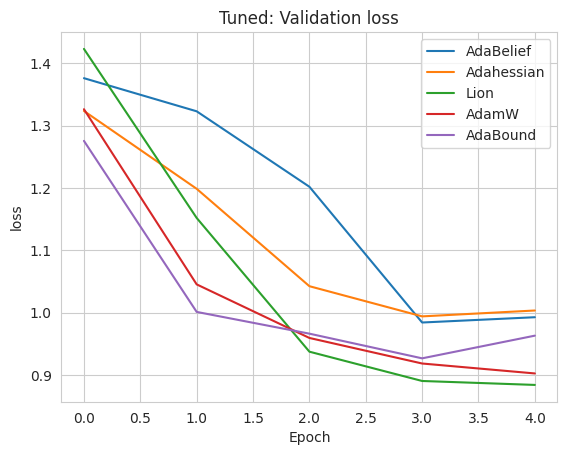


Plot saved to tuned_run_plots/best_tuned_run_accuracy.png


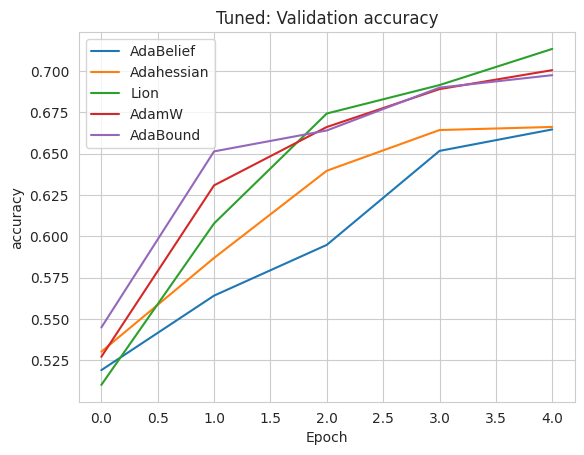


Plot saved to tuned_run_plots/best_tuned_run_f1score.png


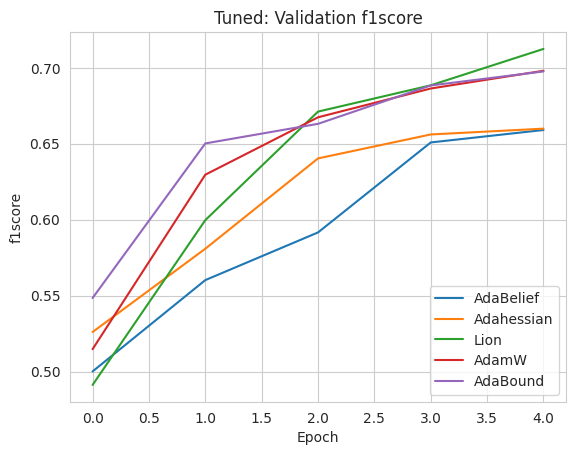


Plot saved to tuned_run_plots/best_tuned_run_precision.png


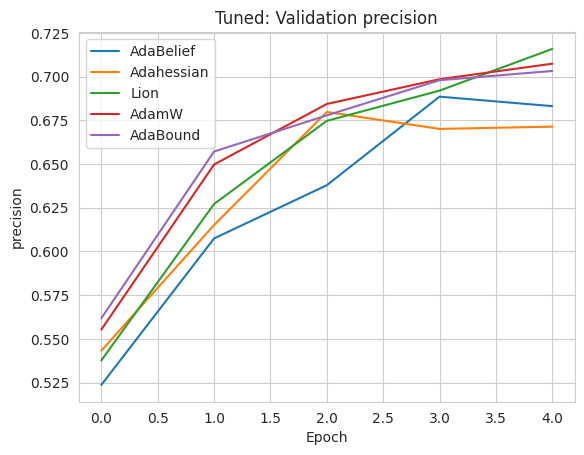


Plot saved to tuned_run_plots/best_tuned_run_recall.png


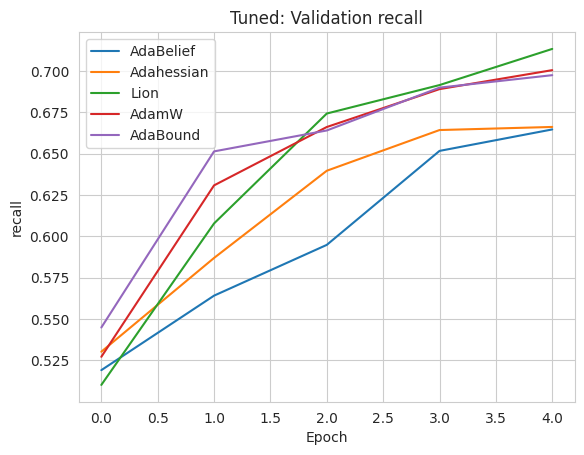

In [15]:
for metric in tuned_val_metric_dfs[next(iter(tuned_val_metric_dfs))]:
    for opt_cls in tuned_val_metric_dfs:
        plt.plot(tuned_val_metric_dfs[opt_cls][metric]['step'][:-1], tuned_val_metric_dfs[opt_cls][metric]['value'][:-1], label=opt_cls)
    plt.title(f'Tuned: Validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    output_filename = f"tuned_run_plots/best_tuned_run_{metric}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved to {output_filename}")
    plt.show()

In [16]:
default_results = {}

experiment_name = "default_image_classification"
experiment_id = get_or_create_experiment("default_image_classification")
mlflow.set_experiment(experiment_id=experiment_id)

for optimizer_type in OPTIMIZERS_PARAMS.keys():
    with mlflow.start_run(run_name=experiment_name+f"_opt_{str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]}") as run:
        model = resnet18(num_classes=num_classes)
        loss_fn = nn.CrossEntropyLoss()
        wrapper = LightningWrapper(model=model, 
                                   optimizer_class=optimizer_type, 
                                   optimizer_hparams={}, 
                                   loss_fn=loss_fn, )
        mlflow.pytorch.autolog()
        trainer = pl.Trainer(#callbacks=[tune_callback, ],
                            limit_train_batches=BATCH_SIZE, 
                            max_epochs=NUM_EPOCHS,
                            accelerator="auto",
                            devices="auto",
                            enable_progress_bar=False,
                            #strategy="ddp_notebook",
                            enable_checkpointing=False,
                            #logger=False,
        )
        start = time.perf_counter()
        trainer.fit(model=wrapper, 
                    train_dataloaders=cifar_train_dataloader,
                    val_dataloaders=cifar_valid_dataloader,)
        end = time.perf_counter()
        time_training = end - start
        metrics_to_save = trainer.test(model=wrapper, dataloaders=cifar_test_dataloader)[0]
        metrics_to_save = {
            "test_accuracy": metrics_to_save.get("test_accuracy", 0.),
            "test_f1score": metrics_to_save.get("test_f1score", 0.),
            "test_precision": metrics_to_save.get("test_precision", 0.),
            "test_recall": metrics_to_save.get("test_recall", 0.),
        }
        metrics_to_save['time_training'] = time_training
        optimizer_name = 'default_' + str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
        print(f"{optimizer_name} was trained for {time_training} seconds")
        default_results[optimizer_name] = metrics_to_save


Please check your arguments if you have upgraded adabelief-pytorch from version 0.0.5.
Modifications to default arguments:
                           eps  weight_decouple    rectify
-----------------------  -----  -----------------  ---------
adabelief-pytorch=0.0.5  1e-08  False              False
>=0.1.0 (Current 0.2.0)  1e-16  True               True
SGD better than Adam (e.g. CNN for Image Classification)    Adam better than SGD (e.g. Transformer, GAN)
----------------------------------------------------------  ----------------------------------------------
Recommended eps = 1e-8                                      Recommended eps = 1e-16
For a complete table of recommended hyperparameters, see
https://github.com/juntang-zhuang/Adabelief-Optimizer
You can disable the log message by setting "print_change_log = False", though it is recommended to keep as a reminder.

Weight decoupling enabled in AdaBelief
Rectification enabled in AdaBelief


2025/10/27 23:19:22 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:19:33 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:19:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6238999962806702     │
│       test_f1score        │    0.6265167593955994     │
│         test_loss         │    1.1283910274505615     │
│      test_precision       │    0.6516352295875549     │
│        test_recall        │    0.6238999962806702     │
└───────────────────────────┴───────────────────────────┘

default_AdaBelief was trained for 80.0788918090002 seconds


2025/10/27 23:22:32 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:22:42 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:22:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │     0.676300048828125     │
│       test_f1score        │    0.6739991307258606     │
│         test_loss         │    0.9751161336898804     │
│      test_precision       │    0.7041994333267212     │
│        test_recall        │     0.676300048828125     │
└───────────────────────────┴───────────────────────────┘

default_AdamW was trained for 79.06971357599832 seconds


2025/10/27 23:26:30 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:26:40 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:26:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6832999587059021     │
│       test_f1score        │    0.6825730800628662     │
│         test_loss         │    1.0085314512252808     │
│      test_precision       │    0.6961373686790466     │
│        test_recall        │    0.6832999587059021     │
└───────────────────────────┴───────────────────────────┘

default_AdaBound was trained for 75.73456440100199 seconds


In [17]:
default_val_metric_dfs = {}
experiment_name = "default_image_classification"
experiment_id = get_or_create_experiment("default_image_classification")
for opt_cls in default_results:
    analysis = default_results[opt_cls]
    mlflow_run_id = mlflow.search_runs(experiment_ids=[experiment_id], filter_string=f"attributes.run_name = '{experiment_name}_opt_{opt_cls[opt_cls.find('_') + 1:]}'").sort_values(by='start_time', ascending=False).iloc[0]['run_id']
    default_val_metric_dfs[opt_cls] = {}
    default_val_metric_dfs[opt_cls]['loss'] = get_metric_history_df(mlflow_run_id, "val_loss")
    default_val_metric_dfs[opt_cls]['accuracy'] = get_metric_history_df(mlflow_run_id, "val_accuracy")
    default_val_metric_dfs[opt_cls]['f1score'] = get_metric_history_df(mlflow_run_id, "val_f1score")
    default_val_metric_dfs[opt_cls]['precision'] = get_metric_history_df(mlflow_run_id, "val_precision")
    default_val_metric_dfs[opt_cls]['recall'] = get_metric_history_df(mlflow_run_id, "val_recall")
    print(f"Running for {opt_cls=}")
    print("\nValidation Loss History:")
    print(default_val_metric_dfs[opt_cls]['loss'].head())

Running for opt_cls='default_AdaBelief'

Validation Loss History:
   step     value               timestamp
0     0  1.425057 2025-10-27 23:18:26.550
1     1  1.288218 2025-10-27 23:18:40.076
2     2  1.152669 2025-10-27 23:18:53.830
3     3  1.128229 2025-10-27 23:19:07.617
4     4  1.121108 2025-10-27 23:19:21.246
Running for opt_cls='default_Adahessian'

Validation Loss History:
   step     value               timestamp
0     0  1.293714 2025-10-27 23:20:10.332
1     1  1.100757 2025-10-27 23:20:45.348
2     2  1.056214 2025-10-27 23:21:19.989
3     3  1.083963 2025-10-27 23:21:56.461
4     4  0.962010 2025-10-27 23:22:30.444
Running for opt_cls='default_Lion'

Validation Loss History:
   step     value               timestamp
0     0  1.325042 2025-10-27 23:22:57.607
1     1  1.041735 2025-10-27 23:23:10.758
2     2  0.946467 2025-10-27 23:23:24.278
3     3  0.957495 2025-10-27 23:23:37.668
4     4  1.036383 2025-10-27 23:23:50.001
Running for opt_cls='default_AdamW'

Validation Lo


Plot saved to default_run_plots/best_default_run_loss.png


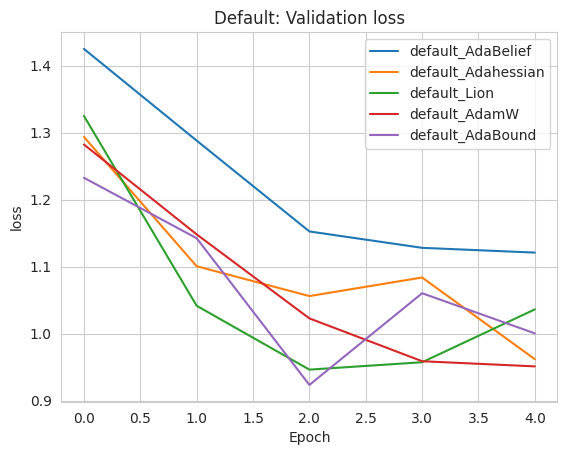


Plot saved to default_run_plots/best_default_run_accuracy.png


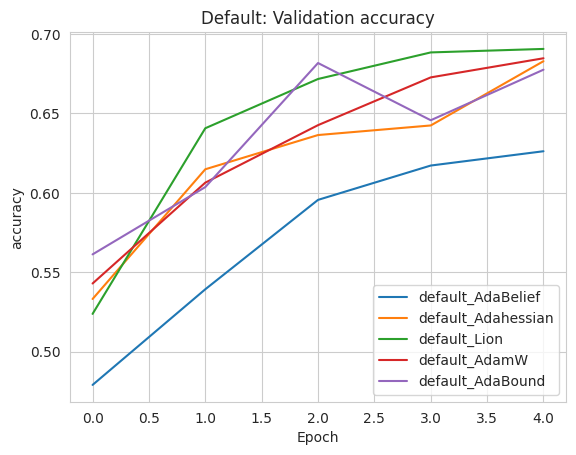


Plot saved to default_run_plots/best_default_run_f1score.png


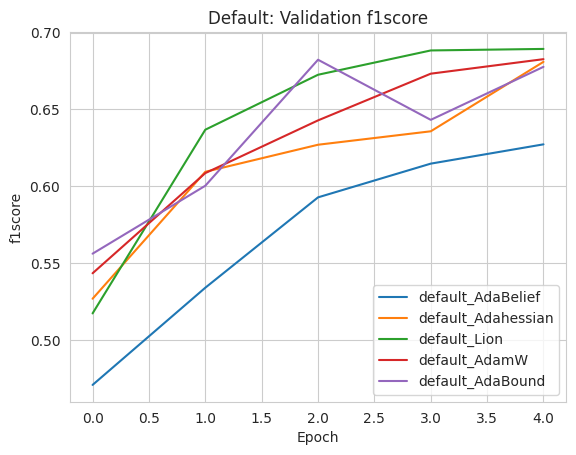


Plot saved to default_run_plots/best_default_run_precision.png


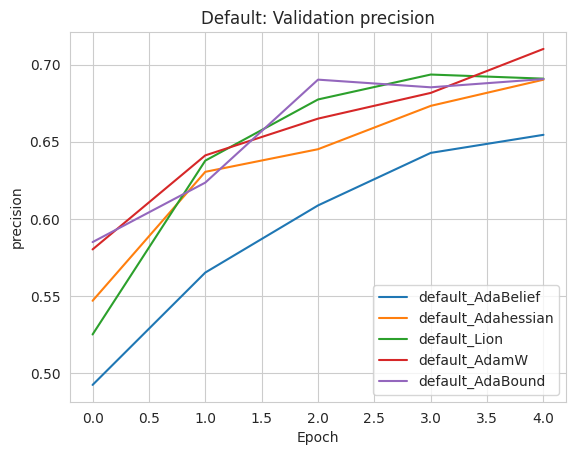


Plot saved to default_run_plots/best_default_run_recall.png


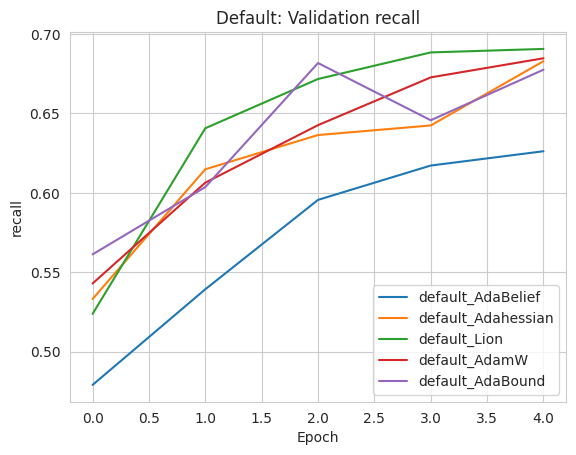

In [18]:
for metric in default_val_metric_dfs[next(iter(default_val_metric_dfs))]:
    for opt_cls in default_val_metric_dfs:
        plt.plot(default_val_metric_dfs[opt_cls][metric]['step'][:-1], default_val_metric_dfs[opt_cls][metric]['value'][:-1], label=opt_cls)
    plt.title(f'Default: Validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    output_filename = f"default_run_plots/best_default_run_{metric}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved to {output_filename}")
    plt.show()


In [19]:
results_df = pd.DataFrame(results).T
results_df = pd.concat([results_df, pd.DataFrame(optimizer_comparison_acc_df['Config']).set_index(results_df.index)], axis=1)
results_df

,test_accuracy,test_f1score,test_precision,test_recall,time_training,Config
AdaBelief,0.6608,0.655167,0.678616,0.6608,84.912902,"{'lr': 0.01, 'weight_decay': 0.01, 'amsgrad': False, 'weight_decouple': True, 'rectify': True, 'print_change_log': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
Adahessian,0.6764,0.670425,0.684826,0.6764,186.344870,"{'lr': 0.1, 'weight_decay': 0, 'hessian_power': 0.75, 'seed': 0, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
Lion,0.7163,0.714932,0.717327,0.7163,75.792153,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
AdamW,0.7014,0.698016,0.707470,0.7014,78.021666,"{'lr': 0.001, 'weight_decay': 0, 'amsgrad': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
AdaBound,0.6923,0.692817,0.697672,0.6923,80.597054,"{'lr': 0.001, 'final_lr': 0.01, 'gamma': 0.0001, 'weight_decay': 0, 'amsbound': True, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"


In [20]:
results_df = pd.DataFrame(results).T
results_df = pd.concat([results_df, pd.DataFrame(optimizer_comparison_acc_df['Config']).set_index(results_df.index)], axis=1)

default_results_df = pd.DataFrame(default_results).T
default_results_df['Config'] = [{i: j for i, j in zip(inspect.getfullargspec(optimizer.__init__).args[2:], inspect.getfullargspec(optimizer.__init__).defaults)} for optimizer in OPTIMIZERS_PARAMS]

pd.concat([results_df, default_results_df])

,test_accuracy,test_f1score,test_precision,test_recall,time_training,Config
AdaBelief,0.6608,0.655167,0.678616,0.6608,84.912902,"{'lr': 0.01, 'weight_decay': 0.01, 'amsgrad': False, 'weight_decouple': True, 'rectify': True, 'print_change_log': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
Adahessian,0.6764,0.670425,0.684826,0.6764,186.344870,"{'lr': 0.1, 'weight_decay': 0, 'hessian_power': 0.75, 'seed': 0, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
Lion,0.7163,0.714932,0.717327,0.7163,75.792153,"{'lr': 0.001, 'weight_decay': 0.001, 'decoupled_weight_decay': False, 'use_triton': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
AdamW,0.7014,0.698016,0.707470,0.7014,78.021666,"{'lr': 0.001, 'weight_decay': 0, 'amsgrad': False, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
AdaBound,0.6923,0.692817,0.697672,0.6923,80.597054,"{'lr': 0.001, 'final_lr': 0.01, 'gamma': 0.0001, 'weight_decay': 0, 'amsbound': True, 'experiment_name': 'image_classification', 'tracking_uri': './mlruns'}"
default_AdaBelief,0.6239,0.626517,0.651635,0.6239,80.078892,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-16, 'weight_decay': 0, 'amsgrad': False, 'weight_decouple': True, 'fixed_decay': False, 'rectify': True, 'degenerated_to_sgd': True, 'print_change_log': True}"
default_Adahessian,0.6804,0.678277,0.686327,0.6804,187.107369,"{'lr': 0.15, 'betas': (0.9, 0.999), 'eps': 0.0001, 'weight_decay': 0, 'hessian_power': 0.5, 'seed': None}"
default_Lion,0.6903,0.689267,0.690960,0.6903,76.411094,"{'lr': 0.0001, 'betas': (0.9, 0.99), 'weight_decay': 0.0, 'use_triton': False, 'decoupled_weight_decay': False}"
default_AdamW,0.6763,0.673999,0.704199,0.6763,79.069714,"{'lr': 0.001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0.01, 'amsgrad': False}"
default_AdaBound,0.6833,0.682573,0.696137,0.6833,75.734564,"{'lr': 0.001, 'betas': (0.9, 0.999), 'final_lr': 0.1, 'gamma': 0.001, 'eps': 1e-08, 'weight_decay': 0, 'amsbound': False}"


In [21]:
cifar_train_dataloader = DataLoader(dataset=ray.get(cifar_train_subset_ref),
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)
cifar_valid_dataloader = DataLoader(dataset=ray.get(cifar_valid_subset_ref),
                                   batch_size=BATCH_SIZE,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)
cifar_test_dataloader = DataLoader(dataset=ray.get(cifar_testset_ref),
                                   batch_size=BATCH_SIZE,
                                   num_workers=2,
                                   worker_init_fn=seed_worker,
                                   generator=TORCH_GENERATOR,)

experiment_name = "tuned_image_classification_rs"
experiment_id = get_or_create_experiment(experiment_name)
mlflow.set_experiment(experiment_id=experiment_id)

rs_results = {}
random_seeds = np.random.randint(low=0, high=10**8, size=10)
for optimizer_type, config in zip(OPTIMIZERS_PARAMS.keys(), optimizer_comparison_acc_df["Config"]):
    rs_results[optimizer_type] = []
    for rs in random_seeds:
        seed_everything(rs)
        with mlflow.start_run(run_name=experiment_name+f"_opt_{str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]}_rs_{rs}") as run:
            model = resnet18(num_classes=num_classes)
            loss_fn = nn.CrossEntropyLoss()
            wrapper = LightningWrapper(model=model, 
                                       optimizer_class=optimizer_type, 
                                       optimizer_hparams={i: j for i, j in config.items() if i not in ["experiment_name", "tracking_uri"]}, 
                                       loss_fn=loss_fn, )
            mlflow.pytorch.autolog()
            trainer = pl.Trainer(#callbacks=[tune_callback, ],
                                limit_train_batches=BATCH_SIZE, 
                                max_epochs=NUM_EPOCHS,
                                accelerator="auto",
                                devices="auto",
                                enable_progress_bar=False,
                                #strategy="ddp_notebook",
                                enable_checkpointing=False,
                                #logger=False,
            )
            start = time.perf_counter()
            trainer.fit(model=wrapper, 
                        train_dataloaders=cifar_train_dataloader,
                        val_dataloaders=cifar_valid_dataloader,)
            end = time.perf_counter()
            time_training = end - start
            # final_metrics = trainer.callback_metrics
            metrics_to_save = trainer.test(model=wrapper, dataloaders=cifar_test_dataloader)[0]
            # print(metrics_to_save)
            metrics_to_save = {
                "test_accuracy": metrics_to_save.get("test_accuracy", 0.),
                "test_f1score": metrics_to_save.get("test_f1score", 0.),
                "test_precision": metrics_to_save.get("test_precision", 0.),
                "test_recall": metrics_to_save.get("test_recall", 0.),
            }
            
            metrics_to_save['time_training'] = time_training
            metrics_to_save['random_state'] = rs
            optimizer_name = str(optimizer_type)[str(optimizer_type).rfind('.')+1:-2]
            print(f"{optimizer_name} with random state {rs} was trained for {time_training} seconds")
            rs_results[optimizer_type].append(metrics_to_save)


Weight decoupling enabled in AdaBelief
Rectification enabled in AdaBelief


2025/10/27 23:27:53 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:28:03 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:28:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6886000037193298     │
│       test_f1score        │    0.6866018772125244     │
│         test_loss         │    0.9540753960609436     │
│      test_precision       │    0.7012354731559753     │
│        test_recall        │    0.6886000037193298     │
└───────────────────────────┴───────────────────────────┘

AdaBelief with random state 53378086 was trained for 77.19938508999985 seconds
Weight decoupling enabled in AdaBelief
Rectification enabled in AdaBelief


2025/10/27 23:29:11 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:29:22 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/27 23:29:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6870999932289124     │
│       test_f1score        │    0.6840409636497498     │
│         test_loss         │    1.0231353044509888     │
│      test_precision       │    0.6968113780021667     │
│        test_recall        │    0.6870999932289124     │
└───────────────────────────┴───────────────────────────┘

AdaBound with random state 97580402 was trained for 82.73262312699808 seconds


2025/10/28 00:51:36 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/28 00:51:47 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.21.0+cu124) contains a local version label (+cu124). MLflow logged a pip requirement for this package as 'torchvision==0.21.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/10/28 00:51:47 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.6970000267028809     │
│       test_f1score        │    0.6966092586517334     │
│         test_loss         │    0.9539710879325867     │
│      test_precision       │     0.699705183506012     │
│        test_recall        │    0.6970000267028809     │
└───────────────────────────┴───────────────────────────┘

AdaBound with random state 68124467 was trained for 83.88888650199806 seconds


In [23]:
rs_dfs = pd.DataFrame([
    result_dict | {'optimizer': str(optimizer_key)[str(optimizer_key).rfind('.') + 1: -2]}
    for optimizer_key in rs_results
    for result_dict in rs_results[optimizer_key]
])
rs_dfs

,test_accuracy,test_f1score,test_precision,test_recall,time_training,random_state,optimizer
0,0.6886,0.686602,0.701235,0.6886,77.199385,53378086,AdaBelief
1,0.6802,0.681606,0.698487,0.6802,77.398947,99938049,AdaBelief
2,0.6840,0.686329,0.709353,0.6840,77.132775,6226186,AdaBelief
3,0.7103,0.708533,0.716632,0.7103,77.220613,53914630,AdaBelief
4,0.6952,0.699143,0.719856,0.6952,77.783906,43193606,AdaBelief
5,0.6964,0.693221,0.707532,0.6964,75.574672,98083430,AdaBelief
6,0.7136,0.715244,0.723966,0.7136,76.928918,78999462,AdaBelief
7,0.6272,0.634674,0.686098,0.6272,75.246924,33861963,AdaBelief
8,0.7175,0.715224,0.717560,0.7175,76.423716,97580402,AdaBelief
9,0.6611,0.650877,0.683743,0.6611,74.860035,68124467,AdaBelief



Plot saved to varying_rs_run_plots/best_run_rs_test_accuracy.png


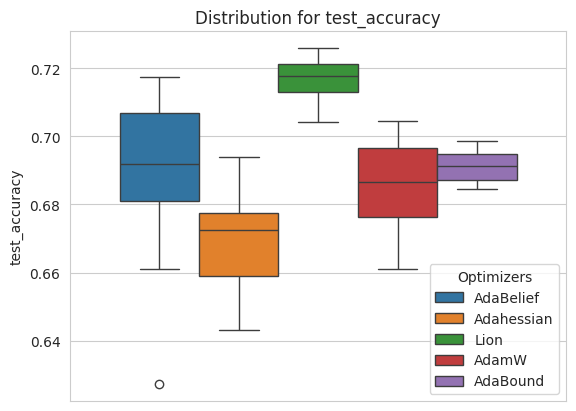


Plot saved to varying_rs_run_plots/best_run_rs_test_f1score.png


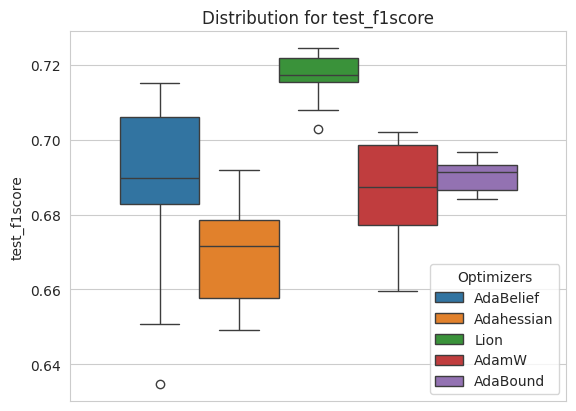


Plot saved to varying_rs_run_plots/best_run_rs_test_precision.png


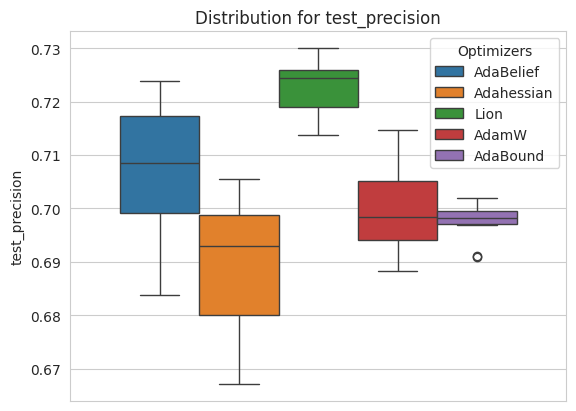


Plot saved to varying_rs_run_plots/best_run_rs_test_recall.png


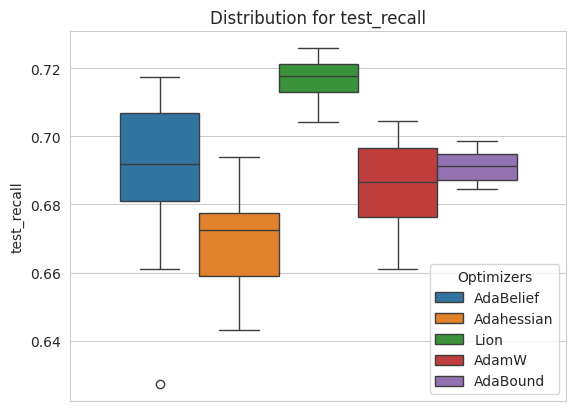

In [25]:
test_metrics = ['test_accuracy', 'test_f1score', 'test_precision', 'test_recall']
for m in test_metrics:
    sns.boxplot(data=rs_dfs, hue='optimizer', y=m)
    plt.legend(title="Optimizers")
    plt.title(f"Distribution for {m}")
    output_filename = f"varying_rs_run_plots/best_run_rs_{m}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\nPlot saved to {output_filename}")
    plt.show()